15.458 Project E
Christine Sinn

Question 2: Pairs Trading

In [1]:
import pandas as pd
import numpy as np
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt

In [2]:
#IMPORTS TRADABLE ASSETS

es1 = pd.read_excel(
    "pairs_data.xlsx",
    sheet_name = "ES1",
    header = 0,
    parse_dates = ["Date"]
)

spy = pd.read_excel("pairs_data.xlsx", sheet_name = "SPY", header = 0, parse_dates = ["Date"])
spx = pd.read_excel("pairs_data.xlsx", sheet_name = "SPX", header = 0, parse_dates = ["Date"])
gld = pd.read_excel("pairs_data.xlsx", sheet_name = "GLD", header = 0, parse_dates = ["Date"])
xau = pd.read_excel("pairs_data.xlsx", sheet_name = "XAU", header = 0, parse_dates = ["Date"])
lmi3 = pd.read_excel("pairs_data.xlsx", sheet_name = "LMI3", header = 0, parse_dates = ["Date"])
mstr = pd.read_excel("pairs_data.xlsx", sheet_name = "MSTR", header = 0, parse_dates = ["Date"])
cl1 = pd.read_excel("pairs_data.xlsx", sheet_name = "CL1", header = 0, parse_dates = ["Date"])
cushing_fred = pd.read_csv("DCOILWTICO.csv", header = 0)
cushing_fred["Date"] = pd.to_datetime(cushing_fred["Date"])

print(cushing_fred.head())

        Date  DCOILWTICO
0 2019-01-02       46.31
1 2019-01-03       46.92
2 2019-01-04       47.76
3 2019-01-07       48.27
4 2019-01-08       49.58


In [3]:
#CONSTRUCT THE PAIRS

#Pair 1: S&P500, ES1 "Generic 1 Month Future" vs. SPX Index Spot
sp_future_spot = pd.merge(es1, spx, how = "inner", on = "Date")
print(sp_future_spot.shape)
print(sp_future_spot.columns)

#Pair 2: S&P500, SPY Equity Index ETF vs. SPX Index Spot
sp_etf_spot = pd.merge(spy, spx, how = "inner", on = "Date")
print(sp_etf_spot.shape)
print(sp_etf_spot.columns)

#Pair 3: Gold, GLD Equity ETF vs. Spot Metal
gold = pd.merge(gld, xau, how = "inner", on = "Date")
print(gold.shape)
print(gold.columns)

#Pair 4: Stocks, GraniteShares 3x Long Microstrategy vs. Microstrategy Stock
stocks = pd.merge(lmi3, mstr, how = "inner", on = "Date")
print(stocks.shape)
print(stocks.columns)

#Pair 5: Oil, WTI 1-month future vs. spot oil
oil = pd.merge(cl1, cushing_fred, how = "inner", on = "Date")
print(oil.shape)
print(oil.columns)

(1760, 3)
Index(['Date', 'ES1', 'SPX'], dtype='str')
(1760, 3)
Index(['Date', 'SPY', 'SPX'], dtype='str')
(1760, 3)
Index(['Date', 'GLD', 'XAU'], dtype='str')
(798, 3)
Index(['Date', 'LMI3_LN', 'MSTR'], dtype='str')
(1763, 3)
Index(['Date', 'CL1', 'DCOILWTICO'], dtype='str')


In [4]:
#CLEANING THE DATA

#Figure out how many trading days in the NYSE calendar during this time
nyse = mcal.get_calendar("NYSE")
schedule = nyse.schedule(start_date = "2019-01-01", end_date = "2025-12-31")
trading_days = schedule.index.normalize()
print(len(trading_days))

#Figure out what dates are extra from the oil dataset
oil["Date"] = pd.to_datetime(oil["Date"])
oil_dates = pd.Index(oil["Date"].dt.normalize())

extra_days = oil_dates.difference(trading_days)
print(extra_days)

#The extra days were Good Fridays in 2021 and 2023 and the National Mourning Day for President Carter, so these days were removed from the oil dataset
oil = oil[~oil["Date"].dt.normalize().isin(extra_days)]
print(oil.shape)

#Check trading days in NYSE calendar during the time when LMI3 has data
schedule2 = nyse.schedule(start_date = "2022-10-06", end_date = "2025-12-31")
trading_days2 = schedule2.index.normalize()
print(len(trading_days2))

stocks_dates = pd.to_datetime(stocks["Date"]).dt.normalize()
missing_days = trading_days2.difference(stocks_dates)
print(missing_days) #14 missing trading days not present in LMI3 LN Equity, not included in pairs dataframe but good to be aware

1760
DatetimeIndex(['2021-04-02', '2023-04-07', '2025-01-09'], dtype='datetime64[us]', freq=None)
(1760, 3)
812
DatetimeIndex(['2022-12-27', '2023-04-10', '2023-05-01', '2023-05-08',
               '2023-08-28', '2023-12-26', '2024-04-01', '2024-05-06',
               '2024-08-26', '2024-12-26', '2025-04-21', '2025-05-05',
               '2025-08-25', '2025-12-26'],
              dtype='datetime64[us]', freq=None)


The R^2 of the trendline is 0.9473570250578068


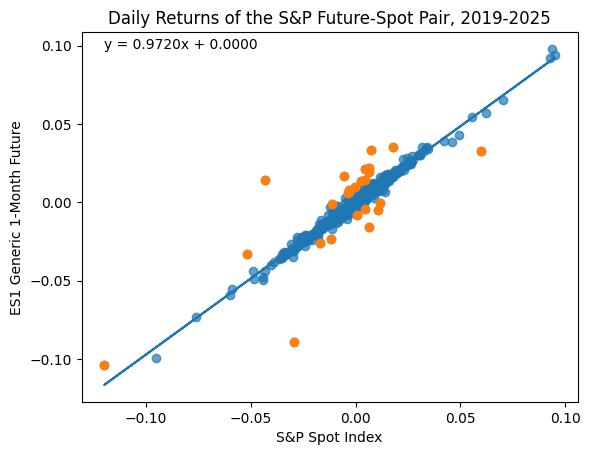

(24, 8)
           Date          z
302  2020-03-16   4.411540
303  2020-03-17  -8.860531
304  2020-03-18   6.150061
305  2020-03-19  -3.145252
306  2020-03-20  19.659969
307  2020-03-23 -21.112670
369  2020-06-19   7.742085
370  2020-06-22  -7.753832
433  2020-09-21  -4.243948
684  2021-09-20  -3.308995
809  2022-03-18  -4.017607
810  2022-03-21   3.520331
1059 2023-03-17   3.411774
1122 2023-06-16   3.340537
1249 2023-12-18   5.771793
1310 2024-03-18   5.561101
1377 2024-06-24   3.892650
1440 2024-09-23   3.723400
1503 2024-12-20  -5.365796
1504 2024-12-23   9.178076
1563 2025-03-21  -3.029349
1564 2025-03-24   6.261670
1689 2025-09-22   3.394515
1753 2025-12-22   4.655090


In [5]:
#PAIR ONE: ES1 vs. SPX

#Find daily simple returns and create a scatterplot
sp_future_spot["r_es1"] = sp_future_spot["ES1"].pct_change()
sp_future_spot["r_spx"] = sp_future_spot["SPX"].pct_change()
sp_future_spot = sp_future_spot.dropna()

x = sp_future_spot["r_spx"]
y = sp_future_spot["r_es1"]

#Find the R^2
corr = np.corrcoef(x, y)[0, 1]
R_squared = corr**2
print(f'The R^2 of the trendline is {R_squared}')

plt.figure()
plt.scatter(x, y, marker = "o", alpha = 0.7)

#Fit the linear trend line
m, b = np.polyfit(x, y, 1)
sp_future_spot["y_hat"] = m * x + b
sp_future_spot["residual"] = y - sp_future_spot["y_hat"]

plt.plot(x, sp_future_spot["y_hat"])

plt.xlabel("S&P Spot Index")
plt.ylabel("ES1 Generic 1-Month Future")
plt.title("Daily Returns of the S&P Future-Spot Pair, 2019-2025")

plt.text(
    x.min(), y.max(), f"y = {m:.4f}x + {b:.4f}"
)

#Figure out outliers in the residuals
sp_future_spot["z"] = (sp_future_spot["residual"] - sp_future_spot["residual"].mean()) / sp_future_spot["residual"].std()
outliers = sp_future_spot[np.abs(sp_future_spot["z"]) > 3]
plt.scatter(outliers["r_spx"], outliers["r_es1"])
plt.show()

print(outliers.shape)
print(outliers[["Date", "z"]])


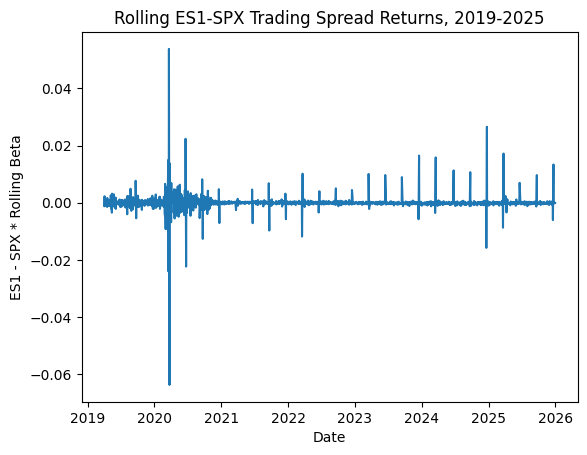

In [6]:
#PAIR ONE SPREAD

#Evaluate a spread trading strategy using rolling 60 day window estimations for the m covarying linear relationship
window = 60
betas = []

for i in range(len(sp_future_spot)):
    if i < window:
        betas.append(np.nan)
    else:
        x_win = sp_future_spot["r_spx"].iloc[i - window:i] #beta computed with information up to day - 1
        y_win = sp_future_spot["r_es1"].iloc[i - window:i]
        m, b = np.polyfit(x_win, y_win, 1)
        betas.append(m)

sp_future_spot["beta_roll"] = betas #beta at row i is the beta computed at day i - 1 used for day i, so no lookahead bias
sp_future_spot["spread"] = sp_future_spot["r_es1"] - sp_future_spot["beta_roll"] * sp_future_spot["r_spx"]

plt.figure()
plt.plot(sp_future_spot["Date"], sp_future_spot["spread"])
plt.xlabel("Date")
plt.ylabel("ES1 - SPX * Rolling Beta")
plt.title("Rolling ES1-SPX Trading Spread Returns, 2019-2025")
plt.show()

The R^2 of the trendline is 0.9952919774297087


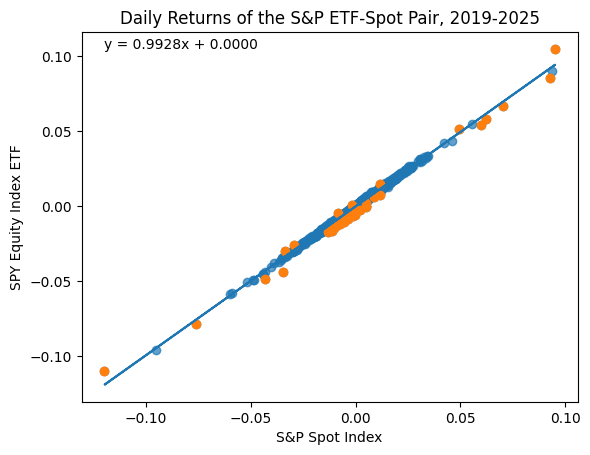

(41, 8)
           Date          z
50   2019-03-15  -5.152961
118  2019-06-21  -5.877472
181  2019-09-20  -5.181357
245  2019-12-20  -6.346460
291  2020-02-28   4.633730
297  2020-03-09  -3.122904
298  2020-03-10   3.151278
301  2020-03-13  -7.832342
302  2020-03-16  11.132022
303  2020-03-17  -6.451616
306  2020-03-20  -6.583838
307  2020-03-23   4.093301
309  2020-03-25   4.098982
310  2020-03-26  -4.170568
311  2020-03-27   4.261514
317  2020-04-06  -3.101591
318  2020-04-07   3.040423
369  2020-06-19  -5.208093
432  2020-09-18  -5.079245
496  2020-12-18  -5.525501
557  2021-03-19  -5.263865
620  2021-06-18  -4.292853
683  2021-09-17  -4.503461
747  2021-12-17  -4.544149
809  2022-03-18  -4.384085
872  2022-06-17  -5.064608
934  2022-09-16  -5.319958
998  2022-12-16  -6.144914
1059 2023-03-17  -5.263997
1122 2023-06-16  -4.026548
1184 2023-09-15  -4.026489
1248 2023-12-15  -6.536895
1309 2024-03-15  -4.093411
1376 2024-06-21  -3.503954
1439 2024-09-20  -3.332637
1563 2025-03-21  -4.

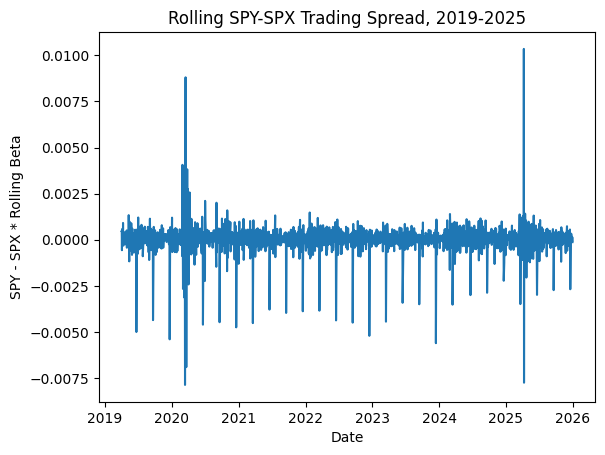

In [7]:
#PAIR TWO: SPY ETF vs. SPX

sp_etf_spot["r_spy"] = sp_etf_spot["SPY"].pct_change()
sp_etf_spot["r_spx"] = sp_etf_spot["SPX"].pct_change()
sp_etf_spot = sp_etf_spot.dropna()

x = sp_etf_spot["r_spx"]
y = sp_etf_spot["r_spy"]

corr2 = np.corrcoef(x, y)[0, 1]
R_squared2 = corr2**2
print(f'The R^2 of the trendline is {R_squared2}')

plt.figure()
plt.scatter(x, y, marker = "o", alpha = 0.7)

m, b = np.polyfit(x, y, 1)
sp_etf_spot["y_pred"] = m * x + b
sp_etf_spot["residual"] = y - sp_etf_spot["y_pred"]

plt.plot(x, sp_etf_spot["y_pred"])
plt.xlabel("S&P Spot Index")
plt.ylabel("SPY Equity Index ETF")
plt.title("Daily Returns of the S&P ETF-Spot Pair, 2019-2025")

plt.text(
    x.min(), y.max(), f'y = {m:.4f}x + {b:.4f}'
)

sp_etf_spot["z"] = (sp_etf_spot["residual"] - sp_etf_spot["residual"].mean()) / sp_etf_spot["residual"].std()
outliers2 = sp_etf_spot[np.abs(sp_etf_spot["z"]) > 3]
plt.scatter(outliers2["r_spx"], outliers2["r_spy"])
plt.show()

print(outliers2.shape)
print(outliers2[["Date", "z"]])

#PAIR TWO SPREAD

#Evaluate a spread trading strategy using rolling 60 day window estimations for the m covarying linear relationship
window = 60
betas = []

for i in range(len(sp_etf_spot)):
    if i < window:
        betas.append(np.nan)
    else:
        x_win = sp_etf_spot["r_spx"].iloc[i - window:i] #beta computed with information up to day - 1
        y_win = sp_etf_spot["r_spy"].iloc[i - window:i]
        m, b = np.polyfit(x_win, y_win, 1)
        betas.append(m)

sp_etf_spot["beta_roll"] = betas #beta at row i is the beta computed at day i - 1 used for day i, so no lookahead bias
sp_etf_spot["spread"] = sp_etf_spot["r_spy"] - sp_etf_spot["beta_roll"] * sp_etf_spot["r_spx"]

plt.figure()
plt.plot(sp_etf_spot["Date"], sp_etf_spot["spread"])
plt.xlabel("Date")
plt.ylabel("SPY - SPX * Rolling Beta")
plt.title("Rolling SPY-SPX Trading Spread, 2019-2025")
plt.show()

#can just flip the trade to make it profitable, spot SPX seems to outperform at pretty consistent periods

The R^2 of the trendline is 0.9728201725728117


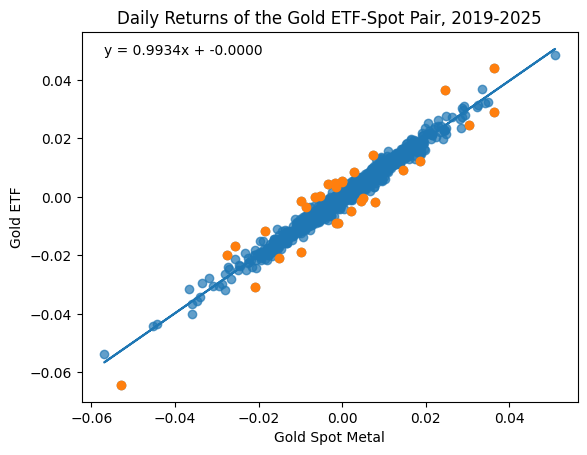

(30, 8)
           Date         z
17   2019-01-28  3.024620
151  2019-08-08  3.168438
299  2020-03-11  3.116387
304  2020-03-18  4.615195
305  2020-03-19 -5.496521
307  2020-03-23  4.895585
312  2020-03-30  4.802739
319  2020-04-08 -4.855035
406  2020-08-12 -4.097280
444  2020-10-06  4.034759
445  2020-10-07 -3.255788
618  2021-06-16  5.212134
619  2021-06-17 -6.054179
688  2021-09-24 -3.446602
732  2021-11-26 -5.725813
733  2021-11-29  5.223135
1059 2023-03-17 -4.251247
1060 2023-03-20  3.416472
1341 2024-05-01 -3.300489
1488 2024-11-29  3.635237
1489 2024-12-02 -4.420005
1575 2025-04-08  3.335476
1577 2025-04-10 -3.487082
1588 2025-04-28  4.273753
1591 2025-05-01 -3.548148
1709 2025-10-20  7.334468
1710 2025-10-21 -7.065905
1711 2025-10-22  4.015553
1737 2025-11-28 -3.672754
1738 2025-12-01  3.986856


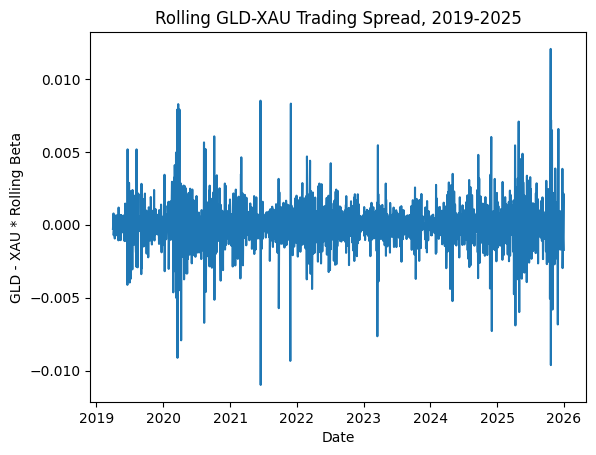

In [8]:
#PAIR THREE: Gold ETF vs. Spot Metal

gold["r_gld"] = gold["GLD"].pct_change()
gold["r_xau"] = gold["XAU"].pct_change()
gold = gold.dropna()

x = gold["r_xau"]
y = gold["r_gld"]

corr3 = np.corrcoef(x, y)[0, 1]
R_squared3 = corr3**2
print(f'The R^2 of the trendline is {R_squared3}')

plt.figure()
plt.scatter(x, y, marker = "o", alpha = 0.7)

m, b = np.polyfit(x, y, 1)
gold["y_pred"] = m * x + b
gold["residual"] = y - gold["y_pred"]

plt.plot(x, gold["y_pred"])
plt.xlabel("Gold Spot Metal")
plt.ylabel("Gold ETF")
plt.title("Daily Returns of the Gold ETF-Spot Pair, 2019-2025")

plt.text(
    x.min(), y.max(), f'y = {m:.4f}x + {b:.4f}'
)

gold["z"] = (gold["residual"] - gold["residual"].mean()) / gold["residual"].std()
outliers3 = gold[np.abs(gold["z"]) > 3]
plt.scatter(outliers3["r_xau"], outliers3["r_gld"])
plt.show()

print(outliers3.shape)
print(outliers3[["Date", "z"]])

#PAIR THREE SPREAD

#Evaluate a spread trading strategy using rolling 60 day window estimations for the m covarying linear relationship
window = 60
betas = []

for i in range(len(gold)):
    if i < window:
        betas.append(np.nan)
    else:
        x_win = gold["r_xau"].iloc[i - window:i] #beta computed with information up to day - 1
        y_win = gold["r_gld"].iloc[i - window:i]
        m, b = np.polyfit(x_win, y_win, 1)
        betas.append(m)

gold["beta_roll"] = betas #beta at row i is the beta computed at day i - 1 used for day i, so no lookahead bias
gold["spread"] = gold["r_gld"] - gold["beta_roll"] * gold["r_xau"]

plt.figure()
plt.plot(gold["Date"], gold["spread"])
plt.xlabel("Date")
plt.ylabel("GLD - XAU * Rolling Beta")
plt.title("Rolling GLD-XAU Trading Spread, 2019-2025")
plt.show()

The R^2 of the trendline is 0.4213268582820125


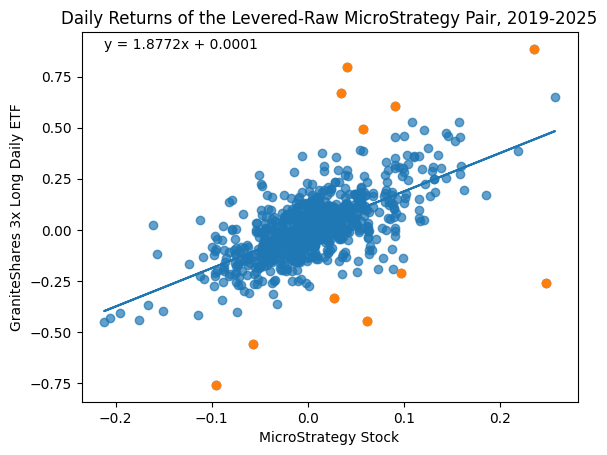

(11, 8)
          Date         z
25  2022-11-10 -3.098959
80  2023-02-02  3.503257
346 2024-03-04  3.565588
351 2024-03-11  5.784978
357 2024-03-19 -3.645632
359 2024-03-21  4.891018
450 2024-08-05 -4.668046
527 2024-11-22 -4.526743
592 2025-03-04 -3.160333
618 2025-04-09 -5.832526
778 2025-12-02  3.101427


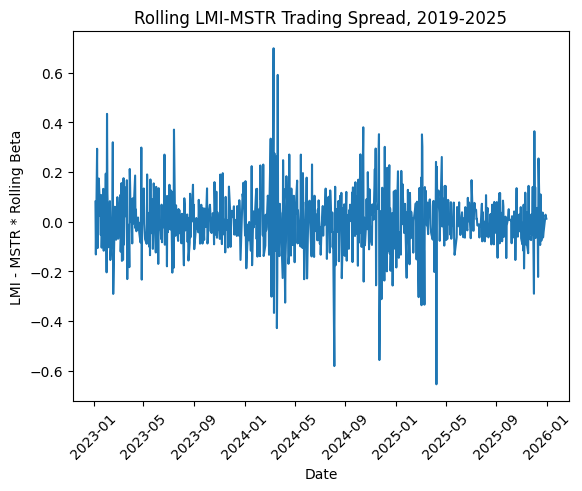

In [9]:
#PAIR FOUR: 3x Levered Long MicroStrategy ETF vs. MicroStrategy Stock

stocks["r_lmi"] = stocks["LMI3_LN"].pct_change()
stocks["r_mstr"] = stocks["MSTR"].pct_change()
stocks = stocks.dropna()

x = stocks["r_mstr"]
y = stocks["r_lmi"]

corr4 = np.corrcoef(x, y)[0, 1]
R_squared4 = corr4**2
print(f'The R^2 of the trendline is {R_squared4}')

plt.figure()
plt.scatter(x, y, marker = "o", alpha = 0.7)

m, b = np.polyfit(x, y, 1)
stocks["y_pred"] = m * x + b
stocks["residual"] = y - stocks["y_pred"]

plt.plot(x, stocks["y_pred"])
plt.xlabel("MicroStrategy Stock")
plt.ylabel("GraniteShares 3x Long Daily ETF")
plt.title("Daily Returns of the Levered-Raw MicroStrategy Pair, 2019-2025")

plt.text(
    x.min(), y.max(), f'y = {m:.4f}x + {b:.4f}'
)

stocks["z"] = (stocks["residual"] - stocks["residual"].mean()) / stocks["residual"].std()
outliers4 = stocks[np.abs(stocks["z"]) > 3]
plt.scatter(outliers4["r_mstr"], outliers4["r_lmi"])
plt.show()

print(outliers4.shape)
print(outliers4[["Date", "z"]])

#PAIR FOUR SPREAD

#Evaluate a spread trading strategy using rolling 60 day window estimations for the m covarying linear relationship
window = 60
betas = []

for i in range(len(stocks)):
    if i < window:
        betas.append(np.nan)
    else:
        x_win = stocks["r_mstr"].iloc[i - window:i] #beta computed with information up to day - 1
        y_win = stocks["r_lmi"].iloc[i - window:i]
        m, b = np.polyfit(x_win, y_win, 1)
        betas.append(m)

stocks["beta_roll"] = betas #beta at row i is the beta computed at day i - 1 used for day i, so no lookahead bias
stocks["spread"] = stocks["r_lmi"] - stocks["beta_roll"] * stocks["r_mstr"]

plt.figure()
plt.plot(stocks["Date"], stocks["spread"])
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("LMI - MSTR * Rolling Beta")
plt.title("Rolling LMI-MSTR Trading Spread, 2019-2025")
plt.show()

The R^2 of the trendline is 0.9750922052453858


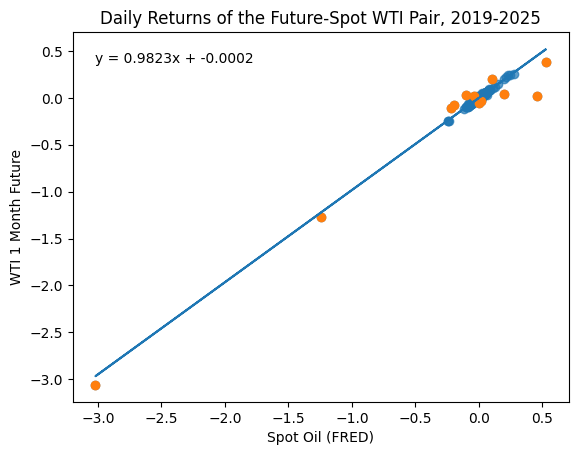

(12, 8)
          Date          z
230 2019-11-29  -3.744558
231 2019-12-02   3.783545
306 2020-03-20   8.122715
307 2020-03-23 -11.335121
308 2020-03-24   9.286286
310 2020-03-26   8.886569
313 2020-03-31 -31.742927
326 2020-04-20  -6.921680
327 2020-04-21  -3.476236
328 2020-04-22 -10.753695
329 2020-04-23   7.089286
332 2020-04-28  -3.923018


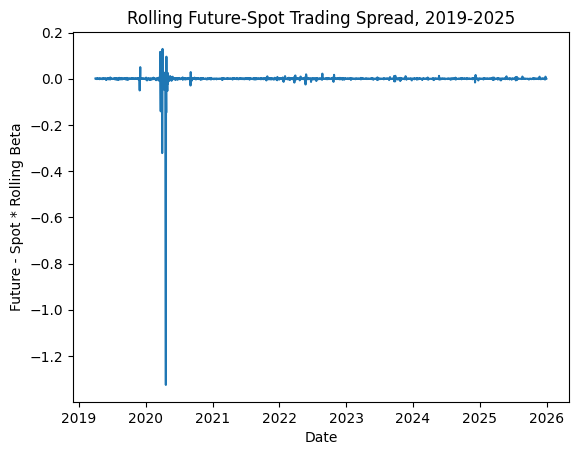

In [93]:
#PAIR FIVE: WTI 1 Month Future vs. Spot Oil

oil["r_future"] = oil["CL1"].pct_change()
oil["r_spot"] = oil["DCOILWTICO"].pct_change()
oil = oil.dropna()

x = oil["r_spot"]
y = oil["r_future"]

corr5 = np.corrcoef(x, y)[0, 1]
R_squared5 = corr5**2
print(f'The R^2 of the trendline is {R_squared5}')

plt.figure()
plt.scatter(x, y, marker = "o", alpha = 0.7)

m, b = np.polyfit(x, y, 1)
oil["y_pred"] = m * x + b
oil["residual"] = y - oil["y_pred"]

plt.plot(x, oil["y_pred"])
plt.xlabel("Spot Oil (FRED)")
plt.ylabel("WTI 1 Month Future")
plt.title("Daily Returns of the Future-Spot WTI Pair, 2019-2025")

plt.text(
    x.min(), y.max(), f'y = {m:.4f}x + {b:.4f}'
)

oil["z"] = (oil["residual"] - oil["residual"].mean()) / oil["residual"].std()
outliers5 = oil[np.abs(oil["z"]) > 3]
plt.scatter(outliers5["r_spot"], outliers5["r_future"])
plt.show()

print(outliers5.shape)
print(outliers5[["Date", "z"]])

#PAIR FIVE SPREAD

#Evaluate a spread trading strategy using rolling 60 day window estimations for the m covarying linear relationship
window = 60
betas = []

for i in range(len(oil)):
    if i < window:
        betas.append(np.nan)
    else:
        x_win = oil["r_spot"].iloc[i - window:i] #beta computed with information up to day - 1
        y_win = oil["r_future"].iloc[i - window:i]
        m, b = np.polyfit(x_win, y_win, 1)
        betas.append(m)

oil["beta_roll"] = betas #beta at row i is the beta computed at day i - 1 used for day i, so no lookahead bias
oil["spread"] = oil["r_future"] - oil["beta_roll"] * oil["r_spot"]

plt.figure()
plt.plot(oil["Date"], oil["spread"])
plt.xlabel("Date")
plt.ylabel("Future - Spot * Rolling Beta")
plt.title("Rolling Future-Spot Trading Spread, 2019-2025")
plt.show()

PART THREE: OPTIONS AND HEDGING

In [10]:
call90 = pd.read_csv(
    "call_90.csv",
    header = 0,
    parse_dates = ["d"]
)

call95 = pd.read_csv(
    "call_95.csv",
    header = 0,
    parse_dates = ["d"]
)

call100 = pd.read_csv(
    "call_100.csv",
    header = 0,
    parse_dates = ["d"]
)

dividend = pd.read_csv(
    "dividend.csv",
    header = 0,
    parse_dates = ["ex_date"]
)

rfr = pd.read_excel(
    "rfr.xlsx",
    header = 0,
    parse_dates = ["d"]
)

# print(call90s.columns)
# print(call90["secid"])
# print(call90[["d", "days"]].tail())

dividend.rename(columns = {"ex_date": "d", "amount": "div_per_share"}, inplace = True)
print(dividend.tail())
# print(rfr.head())
# print(call90.tail())

     secid record_date  seq_num          d  div_per_share  adj_factor  \
7   103823  2009-08-25        1 2009-08-21        0.32866           1   
8   103823  2009-09-22        1 2009-09-18        0.17525           1   
9   103823  2009-10-20        1 2009-10-16        0.09419           1   
10  103823  2009-11-24        1 2009-11-20        0.33798           1   
11  103823  2009-12-22        1 2009-12-18        0.40047           1   

   declare_date payment_date  link_secid  distr_type  frequency    currency  \
7    2009-08-20   2009-09-14           0           1          4  USD          
8    2009-09-17   2009-10-13           0           1          4  USD          
9    2009-10-15   2009-11-16           0           1          4  USD          
10   2009-11-19   2009-12-14           0           1          4  USD          
11   2009-12-17   2010-01-11           0           1          4  USD          

    approx_flag  cancel_flag  liquid_flag  
7             0          NaN            0 

In [11]:
#Create one big database for the different strikes
mkt90 = pd.merge(call90, rfr, how = "inner", on = "d")
mkt90 = pd.merge(mkt90, dividend, how = "left", on = "d")
# mkt90 = pd.merge(mkt90, stock, how = "inner", on = "d")
mkt90["div_per_share"] = mkt90["div_per_share"].fillna(0.0)
mkt90 = mkt90[["d", "days", "bid", "ask", "iv", "delta", "gamma", "vega", "theta", "hedge_err", "id_delta", "moneyness", "spot", "rate", "div_per_share"]]
mkt90 = mkt90.sort_values("d").reset_index(drop = True).copy()
print(mkt90.head())

mkt95 = pd.merge(call95, rfr, how = "inner", on = "d")
mkt95 = pd.merge(mkt95, dividend, how = "left", on = "d")
# mkt95 = pd.merge(mkt95, stock, how = "inner", on = "d")
mkt95["div_per_share"] = mkt95["div_per_share"].fillna(0.0)
mkt95 = mkt95[["d", "days", "bid", "ask", "iv", "delta", "gamma", "vega", "theta", "hedge_err", "id_delta", "moneyness", "spot", "rate", "div_per_share"]]
mkt95 = mkt95.sort_values("d").reset_index(drop = True).copy()
print(mkt95.tail())

mkt100 = pd.merge(call100, rfr, how = "inner", on = "d")
mkt100 = pd.merge(mkt100, dividend, how = "left", on = "d")
# mkt100 = pd.merge(mkt100, stock, how = "inner", on = "d")
mkt100["div_per_share"] = mkt100["div_per_share"].fillna(0.0)
mkt100 = mkt100[["d", "days", "bid", "ask", "iv", "delta", "gamma", "vega", "theta", "hedge_err", "id_delta", "moneyness", "spot", "rate", "div_per_share"]]
mkt100 = mkt100.sort_values("d").reset_index(drop = True).copy()
print(mkt100.tail())

           d   days    bid    ask        iv     delta     gamma      vega  \
0 2009-01-02  262.0  10.90  11.15  0.328586  0.538643  0.013426  35.22894   
1 2009-01-05  261.0  10.30  10.75  0.324395  0.529603  0.013788  34.98693   
2 2009-01-06  260.0  10.55  11.10  0.326646  0.536120  0.013638  35.05752   
3 2009-01-07  259.0   9.60   9.95  0.332751  0.504829  0.013773  34.28823   
4 2009-01-08  258.0   9.35   9.70  0.332815  0.498126  0.013856  34.09599   

      theta  hedge_err  id_delta  moneyness   spot      rate  div_per_share  
0 -6.380461        NaN      50.0   0.997783  90.20  0.003182            0.0  
1 -6.276309        NaN      50.0   1.003344  89.70  0.002940            0.0  
2 -6.349615        NaN      50.0   0.998336  90.15  0.003015            0.0  
3 -6.266254        NaN      50.0   1.024357  87.86  0.002878            0.0  
4 -6.222232        NaN      50.0   1.029395  87.43  0.002698            0.0  
             d  days    bid    ask  iv  delta  gamma  vega  theta  he

In [13]:
#Delta Hedged Portfolio Simulation

#Initialize empty columns to the dataframe
mkt90[["q", "cash", "cash_intra", "MV", "MV_intra", "PNL", "shares_traded"]] = np.nan
mkt95[["q", "cash", "cash_intra", "MV", "MV_intra", "PNL", "shares_traded"]] = np.nan
mkt100[["q", "cash", "cash_intra", "MV", "MV_intra", "PNL", "shares_traded"]] = np.nan

mkt90["K"] = 90
mkt95["K"] = 95
mkt100["K"] = 100

Q = -100 * 45 #held option position (denoted in shares equivalent) - selling 45 calls representing 100 underlying each

for df in [mkt90, mkt95, mkt100]:
    df["V_t"] = ((df["bid"] + df["ask"]) / 2) #midpoint mark to market
    df.loc[df.index[-1], "V_t"] = max(df.loc[df.index[-1], "spot"] - df["K"].iloc[0], 0)
    #Handle the missing Greeks in the last few rows leading up to expiration by incorporating more binary thresholds using the moneyness (S / K) feature
    df["delta_backup"] = df["delta"]
    mask = df["delta_backup"].isna()
    near_exp = (df["days"] <= 10)
    df.loc[mask & near_exp & (df["moneyness"] > 1.01), "delta_backup"] = 1.0
    df.loc[mask & near_exp & (df["moneyness"] < 0.99), "delta_backup"] = 0.0
    df.loc[mask & near_exp & (df["moneyness"].between(0.99, 1.01)), "delta_backup"] = 0.5
    df["delta_backup"] = df["delta_backup"].interpolate().ffill()
    df.loc[df.index[-1], "delta_backup"] = 1.0 if df.loc[df.index[-1], "spot"] > df["K"].iloc[0] else 0.0
    df["vega"] = df["vega"].interpolate().ffill()

    #Initial values
    #Delta, ask value, market value of option, all stored in other columns
    df.loc[0, "q"] = -Q * df["delta"][0] #delta hedge stock position
    df.loc[0, "cash"] = -Q * df["ask"][0] - df["q"][0] * df["spot"][0] #get cash from selling option, lose cash from buying hedge underlying
    df.loc[0, "MV"] = (Q * df["V_t"][0]) + (df["q"][0] * df["spot"][0]) + df["cash"][0] #market value = value of option (marked at mid) + value of stock + value of cash
    df.loc[0, "cash_intra"] = df["cash"][0]
    df.loc[0, "MV_intra"] = df["MV"][0]
    df.loc[0, "PNL"] = 0.0
    df.loc[0, "shares_traded"] = df["q"][0]

    #Recursive update
    for i in range(1, len(df["d"])):
        #Intraday market dynamics
        df.loc[i, "cash_intra"] = (np.exp(df.loc[i, "rate"] / 252) * df.loc[i-1, "cash"]) + (df.loc[i, "div_per_share"] * df.loc[i-1, "q"]) #annualized rates turn into daily continuously compounded trading data
        df.loc[i, "MV_intra"] = (Q * df.loc[i, "V_t"]) + (df.loc[i-1, "q"] * df.loc[i, "spot"]) + df.loc[i, "cash_intra"]
        df.loc[i, "PNL"] = df.loc[i, "MV_intra"] - df.loc[i-1, "MV"]

        #End of day rebalancing
        df.loc[i, "q"] = -Q * df.loc[i, "delta_backup"]
        df.loc[i, "shares_traded"] = df.loc[i, "q"] - df.loc[i-1, "q"]
        df.loc[i, "cash"] = df.loc[i, "cash_intra"] - (df.loc[i, "shares_traded"] * df.loc[i, "spot"])
        df.loc[i, "MV"] = (Q * df.loc[i, "V_t"]) + (df.loc[i, "q"] * df.loc[i, "spot"]) + df.loc[i, "cash"]

print(mkt90.tail())
# print(mkt90.head())
# print(mkt95.head())
# print(mkt100.head())

             d  days    bid    ask  iv  delta  gamma     vega  theta  \
256 2010-01-11   5.0  16.40  16.65 NaN    NaN    NaN  0.77923    NaN   
257 2010-01-12   4.0  15.90  16.25 NaN    NaN    NaN  0.77923    NaN   
258 2010-01-13   3.0  16.65  16.95 NaN    NaN    NaN  0.77923    NaN   
259 2010-01-14   2.0  17.00  17.05 NaN    NaN    NaN  0.77923    NaN   
260 2010-01-15   1.0  15.65  16.20 NaN    NaN    NaN  0.77923    NaN   

     hedge_err  ...       q           cash    cash_intra            MV  \
256        NaN  ...     0.0   93109.194816  93109.194816  18746.694816   
257        NaN  ...     0.0   93109.971077  93109.971077  20772.471077   
258        NaN  ...     0.0   93110.747344  93110.747344  17510.747344   
259        NaN  ...     0.0   93111.523617  93111.523617  16499.023617   
260        NaN  ...  4500.0 -383932.700103  93112.299897  21067.299897   

         MV_intra          PNL  shares_traded   K     V_t  delta_backup  
256  18746.694816 -2249.223746            0.0  9

In [14]:
#Check: This should be equal - all good.
print(mkt90["PNL"].sum())
print(mkt90["MV"][260] - mkt90["MV"][0])
print(mkt95["PNL"].sum())
print(mkt95["MV"][260] - mkt95["MV"][0])
print(mkt100["PNL"].sum())
print(mkt100["MV"][260] - mkt100["MV"][0])

20504.799896872737
20504.799896873184
19936.30564477276
19936.30564477283
22406.54813014222
22406.54813014227


PART A 



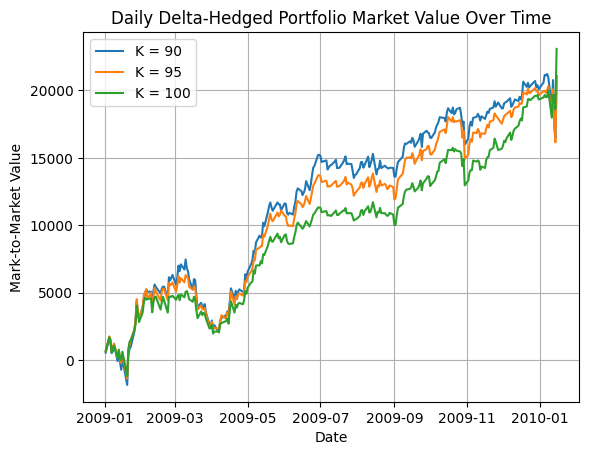

PART B 

The option at strike K = 90 and its delta-hedged portfolio are expected to have a PNL of 562.5
The option at strike K = 95 and its delta-hedged portfolio are expected to have a PNL of 675.0
The option at strike K = 100 and its delta-hedged portfolio are expected to have a PNL of 675.0

 PART C 

The option at strike K = 90 and its delta-hedged portfolio are expected to have a terminal PNL STD of 10767.886669278736
The option at strike K = 95 and its delta-hedged portfolio are expected to have a terminal PNL STD of 10083.39014539627
The option at strike K = 100 and its delta-hedged portfolio are expected to have a terminal PNL STD of 9001.896262712882

 PART D 

The option at strike K = 90 and its delta-hedged portfolio have a final realized PNL (hedging error) of 20504.799896872737
Combined with the theoretical edge in Part B, the final market value of the option portfolio at strike K = 90 is 21067.299896873184
The option at strike K = 95 and its delta-hedged portfolio have a 

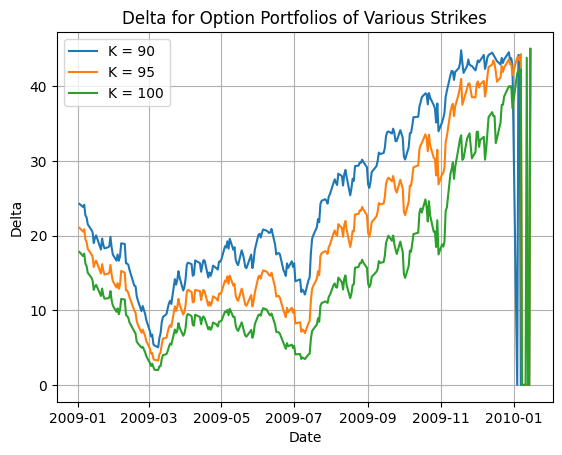

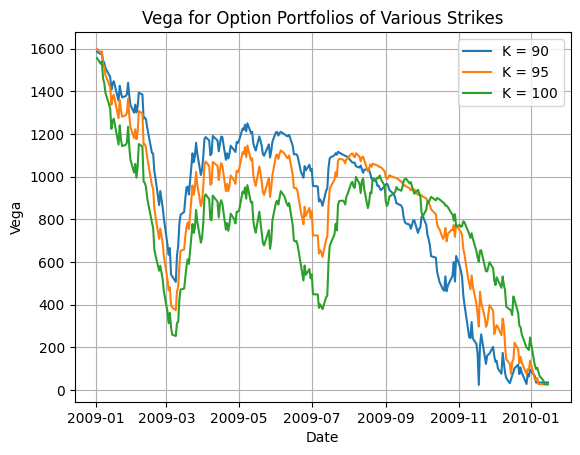


 PART H 



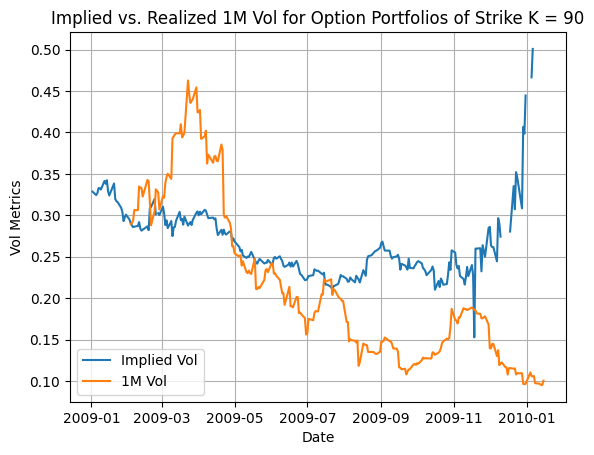

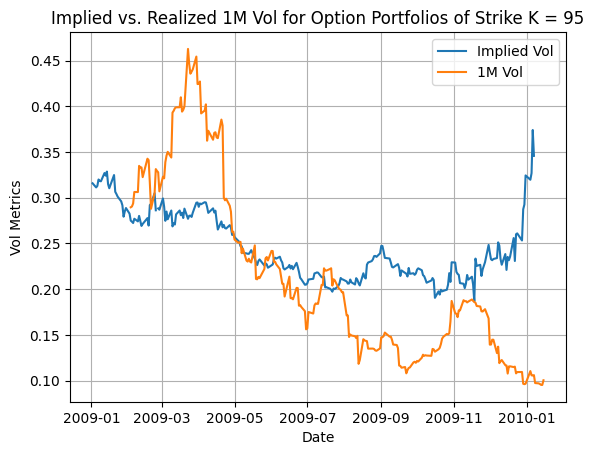

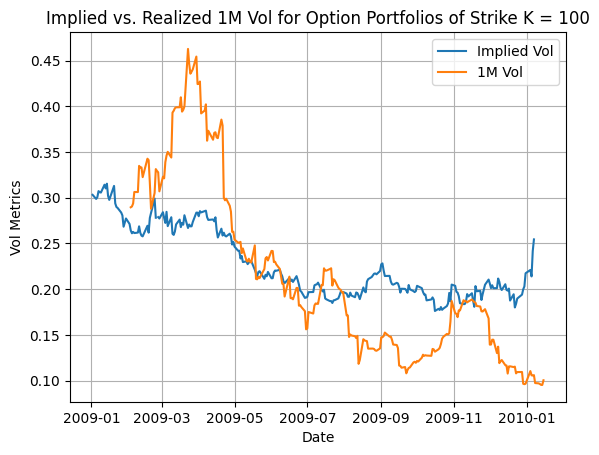


 PART I 



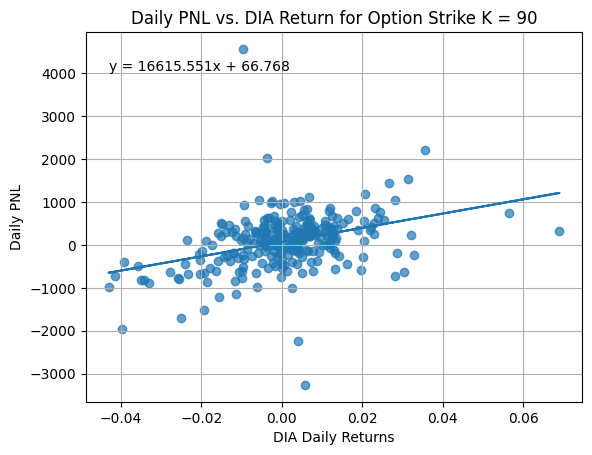

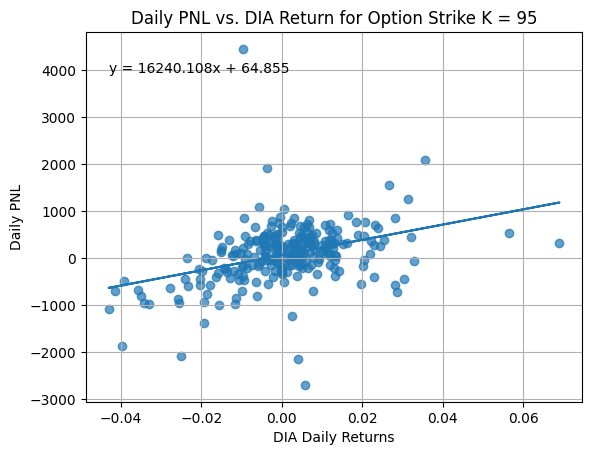

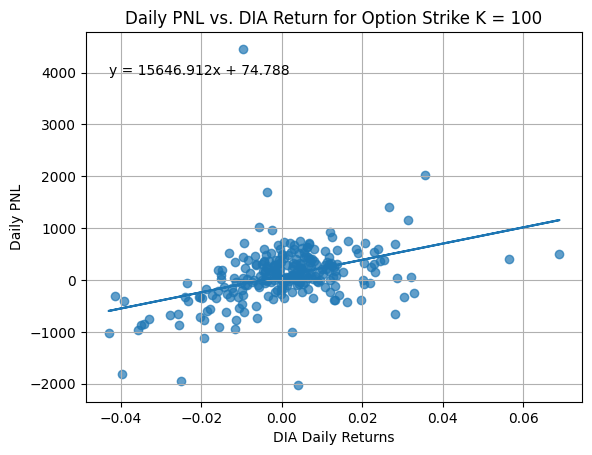

In [15]:
#Answering the questions
trades = {
    "K = 90": mkt90.copy(),
    "K = 95": mkt95.copy(),
    "K = 100": mkt100.copy()
}

#A: Daily Mark to Market Value vs. Time for the Delta Hedged Portfolio
print("PART A \n")
plt.figure()
for name, df in trades.items():
    plt.plot(df["d"], df["MV"], label = name)

plt.xlabel("Date")
plt.ylabel("Mark-to-Market Value")
plt.title("Daily Delta-Hedged Portfolio Market Value Over Time")
plt.legend()
plt.grid(True)
plt.show()

#B: Expected PNL for Lifetime of Trade at Time of Open
#Approximated by the initial marked value of the delta hedged portfolio
#Reflecting bid-ask edge from selling at ask while marking at mid and "perfectly" hedging the path of the option from there till expiration with the stock in the portfolio
print("PART B \n")
for name, df in trades.items():
    print(f'The option at strike {name} and its delta-hedged portfolio are expected to have a PNL of {df.loc[0, "MV"]}')

#C: Estimate the standard deviation of the terminal PNL
#Without making model assumptions and using one singular realized path to maturity, we can estimate the std using the sample std of the daily PNL paths scaled over the time horizon.
print("\n PART C \n")
for name, df in trades.items():
    daily_std = df["PNL"].iloc[1:].std()
    terminal_std = daily_std * np.sqrt(len(df["PNL"].iloc[1:]))
    print(f'The option at strike {name} and its delta-hedged portfolio are expected to have a terminal PNL STD of {terminal_std}')

#D: Determine the final realized PNL of the trade
print("\n PART D \n")
for name, df in trades.items():
    print(f'The option at strike {name} and its delta-hedged portfolio have a final realized PNL (hedging error) of {df["PNL"].iloc[1:].sum()}')
    print(f'Combined with the theoretical edge in Part B, the final market value of the option portfolio at strike {name} is {df["MV"].iloc[-1]}')

#E: Determine annualized standard deviation of PNL over lifetime of the trade
print("\n PART E \n")
for name, df in trades.items():
    daily_std = df["PNL"].iloc[1:].std()
    annual_std = daily_std * np.sqrt(252)
    print(f'The option at strike {name} and its delta-hedged portfolio are expected to have a yearly PNL STD of {annual_std}')

#F: Determine annualized Sharpe ratio for the trade
print("\n PART F \n")
for name, df in trades.items():
    daily_mean = df["PNL"].iloc[1:].mean()
    daily_std = df["PNL"].iloc[1:].std()
    sharpe = (daily_mean / daily_std) * np.sqrt(252)
    print(f'The option at strike {name} and its delta-hedged portfolio have an annualized Sharpe ratio of {sharpe}')

#G: Plot option's delta and vega over time
print("\n PART G \n")
plt.figure()
for name, df in trades.items():
    plt.plot(df["d"], 45 * df["delta_backup"], label = name)

plt.xlabel("Date")
plt.ylabel("Delta")
plt.title("Delta for Option Portfolios of Various Strikes")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for name, df in trades.items():
    plt.plot(df["d"], 45 * df["vega"], label = name)

plt.xlabel("Date")
plt.ylabel("Vega")
plt.title("Vega for Option Portfolios of Various Strikes")
plt.legend()
plt.grid(True)
plt.show()

#H: Plot implied vol over time and compare with realized 1-month vol
print("\n PART H \n")

for name, df in trades.items():
    df["r_dia"] = df["spot"].pct_change() #using simple returns for DIA
    df["rolling_realized_vol"] = df["r_dia"].rolling(21).std() * np.sqrt(252)
    plt.figure()
    plt.plot(df["d"], df["iv"], label = "Implied Vol")
    plt.plot(df["d"], df["rolling_realized_vol"], label = "1M Vol")
    plt.xlabel("Date")
    plt.ylabel("Vol Metrics")
    plt.title(f"Implied vs. Realized 1M Vol for Option Portfolios of Strike {name}")
    plt.legend()
    plt.grid()
    plt.show()

#I: Daily PNL vs. Return on the DIA
print("\n PART I \n")

for name, df in trades.items():
    df["r_dia"] = df["spot"].pct_change() #using simple returns for DIA
    x = df["r_dia"].iloc[1:]
    y = df["PNL"].iloc[1:]
    beta, alpha = np.polyfit(x, y, 1)

    plt.figure()
    plt.scatter(x, y, alpha = 0.7)
    plt.plot(x, alpha + beta * x)
    plt.text(x.min(), y.max() - 500, f'y = {np.round(beta, 3)}x + {np.round(alpha, 3)}')
    plt.xlabel("DIA Daily Returns")
    plt.ylabel("Daily PNL")
    plt.title(f'Daily PNL vs. DIA Return for Option Strike {name}')
    plt.grid()
    plt.show()

PART 4: BUTTERFLY

In [8]:
print(mkt90.columns)
print(mkt90.index[mkt90["d"] == "2009-11-13"][0])
print(mkt90.loc[218, "d"])

Index(['d', 'days', 'bid', 'ask', 'iv', 'delta', 'gamma', 'vega', 'theta',
       'hedge_err', 'id_delta', 'moneyness', 'spot', 'rate', 'div_per_share',
       'q', 'cash', 'cash_intra', 'MV', 'MV_intra', 'PNL', 'shares_traded',
       'K', 'V_t', 'delta_backup'],
      dtype='str')
218
2009-11-13 00:00:00


In [ ]:
#Delta Hedged Portfolio Simulation for Butterfly

#Initialize empty columns to the dataframe
butterfly = mkt90[["d", "days", "spot", "rate", "div_per_share"]].copy()
butterfly = butterfly[butterfly["d"] <= "2009-11-13"]
butterfly[["q", "cash", "cash_intra", "MV", "MV_intra", "PNL", "shares_traded"]] = np.nan

Q90 = -100 * 45 #sell 45 90-strike options (in shares equivalent)
Q95 = 100 * 90 #buy 90 95-strike options (in shares equivalent)
Q100 = -100 * 45 #sell 45 100-strike options (in shares equivalent)

butterfly["delta"] = Q90 * mkt90["delta_backup"] + Q95 * mkt95["delta_backup"] + Q100 * mkt100["delta_backup"]
butterfly["vega"] = Q90 * mkt90["vega"] + Q95 * mkt95["vega"] + Q100 * mkt100["vega"]
butterfly["q"] = -butterfly["delta"] #delta hedge stock position, with quantities of position already incorporated
close_date_idx = butterfly.index[butterfly["d"] == "2009-11-13"][0]

#Initial Values
butterfly.loc[0, "cash"] = - (Q90 * mkt90.loc[0, "ask"] + Q95 * mkt95.loc[0, "bid"] + Q100 * mkt100.loc[0, "ask"]) - butterfly.loc[0, "q"] * butterfly.loc[0, "spot"] #sell butterfly for cash, buy hedge lose cash
butterfly.loc[0, "MV"] = (Q90 * mkt90.loc[0, "V_t"] + Q95 * mkt95.loc[0, "V_t"] + Q100 * mkt100.loc[0, "V_t"]) + (butterfly.loc[0, "q"] * butterfly.loc[0, "spot"]) + butterfly.loc[0, "cash"] #option position + spot hedge + cash
butterfly.loc[0, "cash_intra"] = butterfly["cash"][0]
butterfly.loc[0, "MV_intra"] = butterfly["MV"][0]
butterfly.loc[0, "PNL"] = 0.0
butterfly.loc[0, "shares_traded"] = butterfly["q"][0]

#Recursive update while holding butterfly
for i in range(1, close_date_idx): #through 11/12/2009 (inclusive), then do close transaction on 11/13/2009
    #Intraday market dynamics
    butterfly.loc[i, "cash_intra"] = (np.exp(butterfly.loc[i, "rate"] / 252) * butterfly.loc[i-1, "cash"]) + (butterfly.loc[i, "div_per_share"] * butterfly.loc[i-1, "q"]) #annualized rates turn into daily continuously compounded trading data
    butterfly.loc[i, "MV_intra"] = (Q90 * mkt90.loc[i, "V_t"] + Q95 * mkt95.loc[i, "V_t"] + Q100 * mkt100.loc[i, "V_t"]) + (butterfly.loc[i-1, "q"] * butterfly.loc[i, "spot"]) + butterfly.loc[i, "cash_intra"]
    butterfly.loc[i, "PNL"] = butterfly.loc[i, "MV_intra"] - butterfly.loc[i-1, "MV"]

    #End of day rebalancing - q rebalancing already done above
    butterfly.loc[i, "shares_traded"] = butterfly.loc[i, "q"] - butterfly.loc[i-1, "q"]
    butterfly.loc[i, "cash"] = butterfly.loc[i, "cash_intra"] - (butterfly.loc[i, "shares_traded"] * butterfly.loc[i, "spot"])
    butterfly.loc[i, "MV"] = (Q90 * mkt90.loc[i, "V_t"] + Q95 * mkt95.loc[i, "V_t"] + Q100 * mkt100.loc[i, "V_t"]) + (butterfly.loc[i, "q"] * butterfly.loc[i, "spot"]) + butterfly.loc[i, "cash"] #option position + spot hedge + cash

#On Nov 13 2009, close out position
#carry forward accrued cash and dividends as before
butterfly.loc[close_date_idx, "cash_intra"] = (np.exp(butterfly.loc[close_date_idx, "rate"] / 252) * butterfly.loc[close_date_idx-1, "cash"]) + (butterfly.loc[close_date_idx, "div_per_share"] * butterfly.loc[close_date_idx-1, "q"])
#close out option - buy wings at bid and sell 95s at ask
option_close_cash = (Q90 * mkt90.loc[close_date_idx, "bid"] + Q95 * mkt95.loc[close_date_idx, "ask"] + Q100 * mkt100.loc[close_date_idx, "bid"])
#shares traded is closing out whatever the previous q-1 hedge position was
butterfly.loc[close_date_idx, "q"] = 0.0
butterfly.loc[close_date_idx, "shares_traded"] = butterfly.loc[close_date_idx, "q"] - butterfly.loc[close_date_idx-1, "q"]
#sell stock from the delta hedge of the previous day
stock_close_cash = -butterfly.loc[close_date_idx, "shares_traded"] * butterfly.loc[close_date_idx, "spot"]
butterfly.loc[close_date_idx, "delta"] = 0.0
butterfly.loc[close_date_idx, "vega"] = 0.0
#intraday MV as before
butterfly.loc[close_date_idx, "MV_intra"] = (Q90 * mkt90.loc[close_date_idx, "V_t"] + Q95 * mkt95.loc[close_date_idx, "V_t"] + Q100 * mkt100.loc[close_date_idx, "V_t"]) + (butterfly.loc[close_date_idx-1, "q"] * butterfly.loc[close_date_idx, "spot"]) + butterfly.loc[close_date_idx, "cash_intra"]
#cash is now intraday cash accrued forward + cash from closing out option and stock positions
butterfly.loc[close_date_idx, "cash"] = butterfly.loc[close_date_idx, "cash_intra"] + option_close_cash + stock_close_cash
#PNL is now the terminal cash minus the previous MV
butterfly.loc[close_date_idx, "PNL"] = butterfly.loc[close_date_idx, "cash"] - butterfly.loc[close_date_idx-1, "MV"]
#final MV is just the terminal cash
butterfly.loc[close_date_idx, "MV"] = butterfly.loc[close_date_idx, "cash"]

print(butterfly.tail())

             d  days    spot      rate  div_per_share         q          cash  \
214 2009-11-09  47.0  102.42  0.002194            0.0 -338.4450  39169.647748   
215 2009-11-10  46.0  102.69  0.002194            0.0 -357.2505  41101.125595   
216 2009-11-11  45.0  103.13  0.002194            0.0 -353.0070  40663.851310   
217 2009-11-12  44.0  102.17  0.002194            0.0 -353.8485  40750.181428   
218 2009-11-13  43.0  102.91  0.002194            0.0    0.0000   2535.987107   

       cash_intra           MV     MV_intra         PNL  shares_traded  \
214  39557.717128  1806.110848  1806.110848   86.264728         3.7890   
215  39169.988800  1490.071750  1490.071750 -316.039097       -18.8055   
216  41101.483465  1558.239400  1558.239400   68.167650         4.2435   
217  40664.205373  1559.980183  1559.980183    1.740783        -0.8415   
218  40750.536242  2535.987107  1523.487107  976.006924       353.8485   

        delta       vega  
214  338.4450  2211.0030  
215  357.2505 

In [17]:
#Check: This should be equal - all good.
print(butterfly["PNL"].sum())
print(butterfly["MV"][218] - butterfly["MV"][0])

-51.51289251545222
-51.51289251544995


PART A 



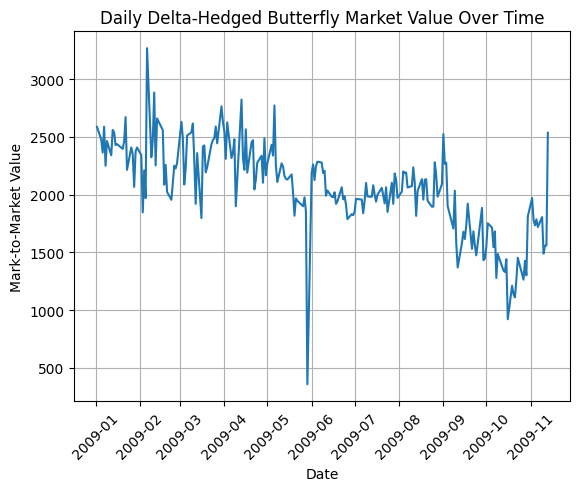

2009-05-29 00:00:00
90 leg: -19237.5
95 leg: 21015.0
100 leg: -6052.5
stock: 7757.724194999982
cash: -3123.7587511332445
bid    1.12
ask    3.55
Name: 101, dtype: float64
-4.9399999999999995 3.0399999999999996


In [18]:
#Answering the questions

#A: Daily Mark to Market Value vs. Time for the Delta Hedged Portfolio
print("PART A \n")
plt.figure()
plt.plot(butterfly["d"], butterfly["MV"])
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Mark-to-Market Value")
plt.title("Daily Delta-Hedged Butterfly Market Value Over Time")
plt.grid(True)
plt.show()

#Investigating the low spike in market value on 5/29/2009
idx = butterfly["MV"].idxmin()
print(butterfly.loc[idx, "d"])

print("90 leg:", Q90 * mkt90.loc[idx, "V_t"])
print("95 leg:", Q95 * mkt95.loc[idx, "V_t"])
print("100 leg:", Q100 * mkt100.loc[idx, "V_t"])
print("stock:", butterfly.loc[idx-1, "q"] * butterfly.loc[idx, "spot"])
print("cash:", butterfly.loc[idx, "cash_intra"])

print(mkt95.loc[idx, ["bid", "ask"]]) #very wide bid-ask spread here of 1.12-3.55
bfly_bid = 2 * mkt95["bid"] - mkt90["ask"] - mkt100["ask"]
bfly_ask = 2 * mkt95["ask"] - mkt90["bid"] - mkt100["bid"]
print(bfly_bid[idx], bfly_ask[idx]) #leads to magnified butterfly bid ask spread

In [20]:
#B: Expected PNL for Lifetime of Trade at Time of Open
#Approximated by the initial marked value of the delta hedged butterfly
#Reflecting bid-ask edge from selling the butterfly while marking at mid and "perfectly" hedging the path of the butterfly from there till expiration with the stock in the portfolio
print("PART B \n")
print(f'The butterfly and its delta-hedged portfolio are expected to have a PNL of {butterfly.loc[0, "MV"]}, assuming held to expiration.')

#C: Estimate the standard deviation of the terminal PNL CHECK TODO
#Without making model assumptions and using one singular realized path to maturity, we can estimate the std using the sample std of the daily PNL paths scaled over the time horizon.
print("\n PART C \n")
daily_std = butterfly["PNL"].iloc[1:].std()
terminal_std = daily_std * np.sqrt(len(butterfly["PNL"].iloc[1:]))
print(f'The butterfly and its delta-hedged portfolio are expected to have a terminal PNL STD of {terminal_std}')

#D: Determine the final realized PNL of the trade
print("\n PART D \n")
print(f'The butterfly and its delta-hedged portfolio have a final realized PNL (hedging error) of {butterfly["PNL"].iloc[1:].sum()}')
print(f'Combined with the theoretical edge in Part B, the final market value of the option portfolio is {butterfly["MV"].iloc[-1]}')

#E: Determine annualized standard deviation of PNL over lifetime of the trade
print("\n PART E \n")
daily_std = butterfly["PNL"].iloc[1:].std()
annual_std = daily_std * np.sqrt(252)
print(f'The butterfly and its delta-hedged portfolio are expected to have a yearly PNL STD of {annual_std}')

#F: Determine annualized Sharpe ratio for the trade
print("\n PART F \n")
daily_mean = butterfly["PNL"].iloc[1:].mean()
daily_std = butterfly["PNL"].iloc[1:].std()
sharpe = (daily_mean / daily_std) * np.sqrt(252)
print(f'The butterfly and its delta-hedged portfolio have an annualized Sharpe ratio of {sharpe}')


PART B 

The butterfly and its delta-hedged portfolio are expected to have a PNL of 2587.5000000000005, assuming held to expiration.

 PART C 

The butterfly and its delta-hedged portfolio are expected to have a terminal PNL STD of 4511.881894200342

 PART D 

The butterfly and its delta-hedged portfolio have a final realized PNL (hedging error) of -51.51289251545222
Combined with the theoretical edge in Part B, the final market value of the option portfolio is 2535.9871074845505

 PART E 

The butterfly and its delta-hedged portfolio are expected to have a yearly PNL STD of 4850.982929460357

 PART F 

The butterfly and its delta-hedged portfolio have an annualized Sharpe ratio of -0.01227524694116174



 PART G 



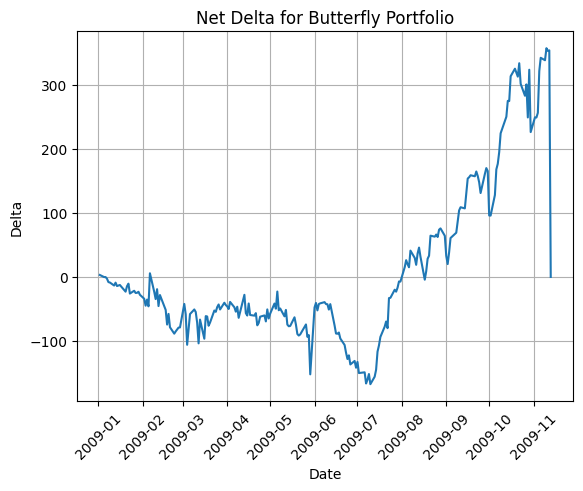

0.0

 PART H 



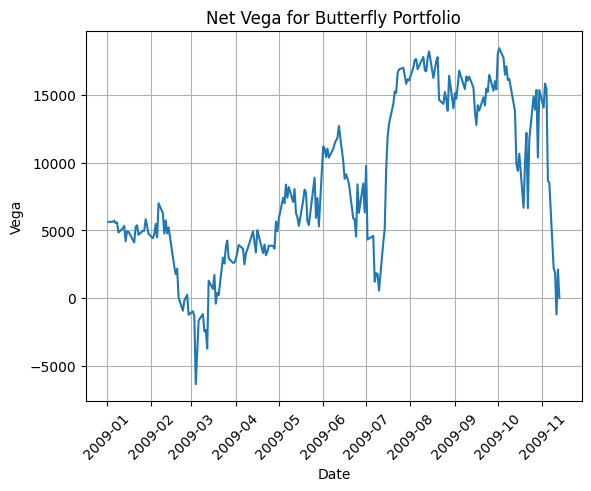

25.87265 22.36576 17.68562
5279.625000000029


In [26]:
#G: Plot option's delta over time
print("\n PART G \n")
plt.figure()
plt.plot(butterfly["d"], butterfly["delta"])
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Delta")
plt.title("Net Delta for Butterfly Portfolio")
plt.grid(True)
plt.show()

print((butterfly["q"] + butterfly["delta"]).abs().max())

#H: Plot option's vega over time
print("\n PART H \n")
plt.figure()
plt.plot(butterfly["d"], butterfly["vega"])
plt.xlabel("Date")
plt.xticks(rotation = 45)
plt.ylabel("Vega")
plt.title("Net Vega for Butterfly Portfolio")
plt.grid(True)
plt.show()

print(mkt90.loc[idx, "vega"], mkt95.loc[idx, "vega"], mkt100.loc[idx, "vega"])
print(butterfly.loc[idx, "vega"])


 PART I 



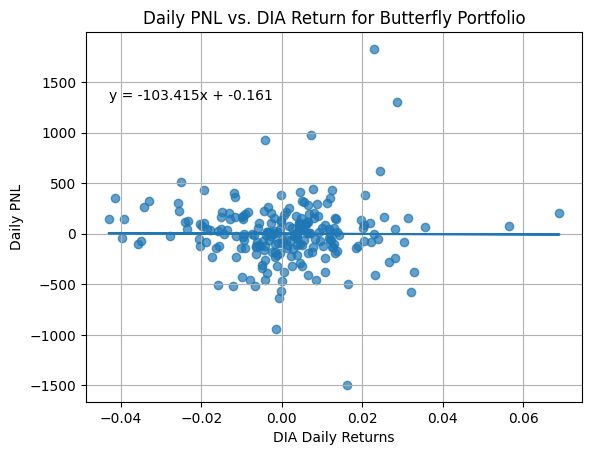

In [27]:
#I: Daily PNL vs. Return on the DIA
print("\n PART I \n")
butterfly["r_dia"] = butterfly["spot"].pct_change() #using simple returns for DIA
x = butterfly["r_dia"].iloc[1:]
y = butterfly["PNL"].iloc[1:]
beta, alpha = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y, alpha = 0.7)
plt.plot(x, alpha + beta * x)
plt.text(x.min(), y.max() - 500, f'y = {np.round(beta, 3)}x + {np.round(alpha, 3)}')
plt.xlabel("DIA Daily Returns")
plt.ylabel("Daily PNL")
plt.title(f'Daily PNL vs. DIA Return for Butterfly Portfolio')
plt.grid()
plt.show()